# Fake Profile Detection using Machine Learning

## Objective:
To detect fake social media profiles using machine learning algorithms.

## Workflow:
1. Data Loading
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Model Training
6. Model Evaluation
7. Hyperparameter Tuning
8. Prediction System

## Algorithms Used:
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- Gradient Boosting

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib

In [11]:
import pandas as pd

df = pd.read_csv("final-v1.csv")  

In [13]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 785
Number of Columns: 13


In [15]:
print("Shape of dataset:", df.shape)
print(df.head())

Shape of dataset: (785, 13)
   edge_followed_by  edge_follow  username_length  username_has_number  \
0             0.001        0.257               13                    1   
1             0.000        0.958                9                    1   
2             0.000        0.253               12                    0   
3             0.000        0.977               10                    1   
4             0.000        0.321               11                    0   

   full_name_has_number  full_name_length  is_private  is_joined_recently  \
0                     1                13           0                   0   
1                     0                 0           0                   1   
2                     0                 0           0                   0   
3                     0                 0           0                   0   
4                     0                11           1                   0   

   has_channel  is_business_account  has_guides  has_external_ur

In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      785 non-null    float64
 1   edge_follow           785 non-null    float64
 2   username_length       785 non-null    int64  
 3   username_has_number   785 non-null    int64  
 4   full_name_has_number  785 non-null    int64  
 5   full_name_length      785 non-null    int64  
 6   is_private            785 non-null    int64  
 7   is_joined_recently    785 non-null    int64  
 8   has_channel           785 non-null    int64  
 9   is_business_account   785 non-null    int64  
 10  has_guides            785 non-null    int64  
 11  has_external_url      785 non-null    int64  
 12  is_fake               785 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 79.9 KB


,edge_followed_by,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,has_channel,is_business_account,has_guides,has_external_url,is_fake
count,785.000000,785.000000,785.000000,785.000000,785.000000,785.000000,785.000000,785.000000,785.0,785.000000,785.000000,785.000000,785.000000
mean,0.002223,0.401606,11.630573,0.644586,0.109554,6.129936,0.184713,0.361783,0.0,0.073885,0.001274,0.062420,0.881529
std,0.036105,0.293845,3.284329,0.478944,0.312532,6.943903,0.388312,0.480823,0.0,0.261751,0.035692,0.242072,0.323371
min,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.135000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.336000,11.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.623000,13.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,26.000000,1.000000,1.000000,30.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000


In [19]:
print("Columns:", df.columns)

Columns: Index(['edge_followed_by', 'edge_follow', 'username_length',
       'username_has_number', 'full_name_has_number', 'full_name_length',
       'is_private', 'is_joined_recently', 'has_channel',
       'is_business_account', 'has_guides', 'has_external_url', 'is_fake'],
      dtype='object')


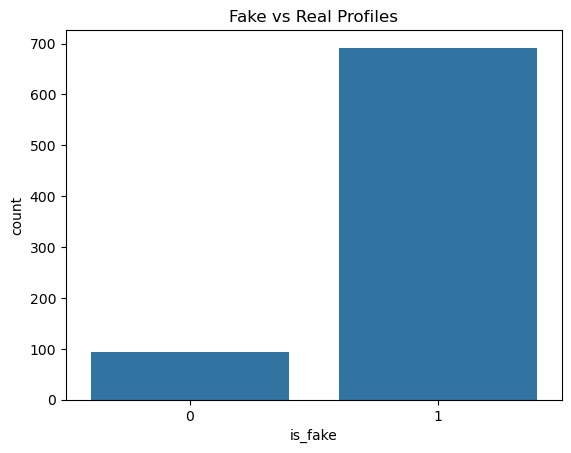

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'is_fake'

sns.countplot(x=target_col, data=df)
plt.title("Fake vs Real Profiles")
plt.show()

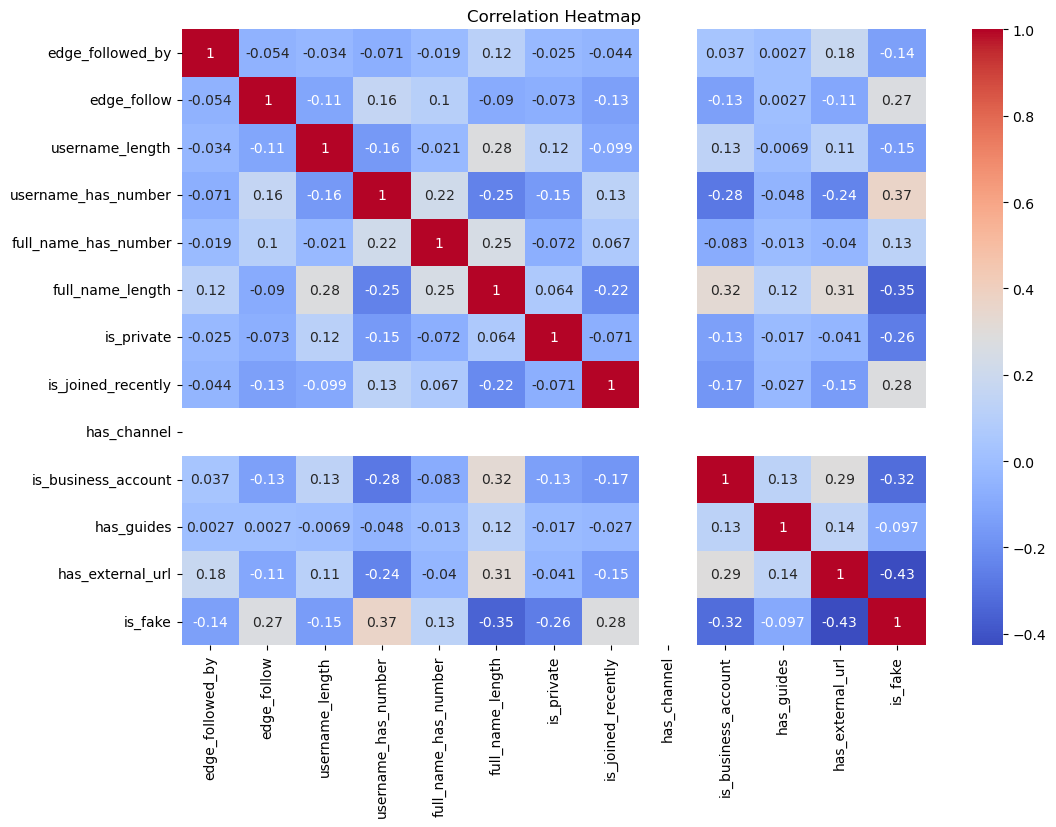

In [23]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [21]:
df['followers_following_ratio'] = df['edge_followed_by'] / (df['edge_follow'] + 1)

In [25]:
df['engagement_score'] = df['edge_followed_by'] * (df['has_external_url'] + 1)

In [27]:
X = df.drop('is_fake', axis=1)
y = df['is_fake']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
lr = LogisticRegression()
svm = SVC(probability=True)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [35]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.9299363057324841
              precision    recall  f1-score   support

           0       0.79      0.58      0.67        19
           1       0.94      0.98      0.96       138

    accuracy                           0.93       157
   macro avg       0.86      0.78      0.81       157
weighted avg       0.92      0.93      0.93       157


SVM
Accuracy: 0.9235668789808917
              precision    recall  f1-score   support

           0       0.77      0.53      0.62        19
           1       0.94      0.98      0.96       138

    accuracy                           0.92       157
   macro avg       0.85      0.75      0.79       157
weighted avg       0.92      0.92      0.92       157


Random Forest
Accuracy: 0.9363057324840764
              precision    recall  f1-score   support

           0       0.91      0.53      0.67        19
           1       0.94      0.99      0.96       138

    accuracy                           0.94       157


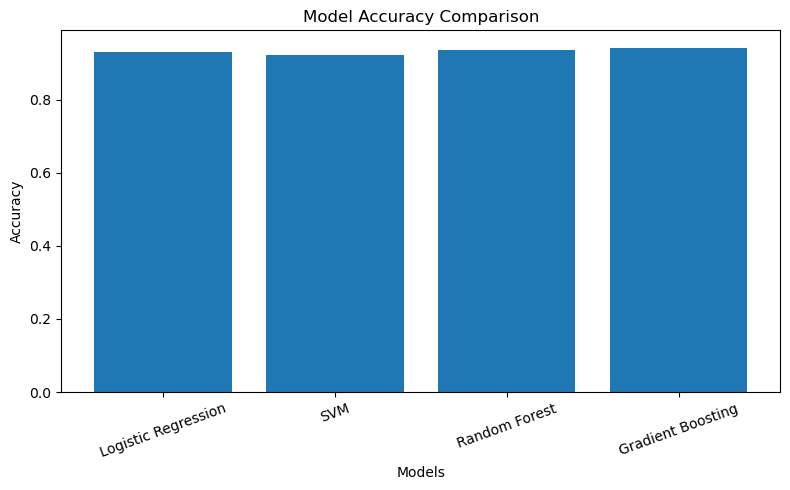

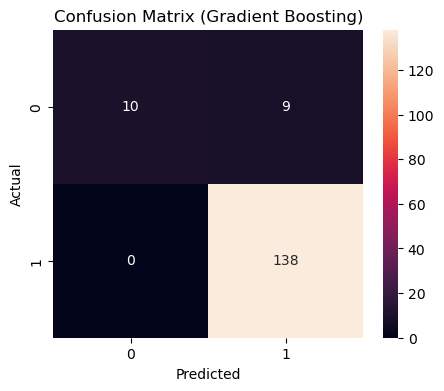

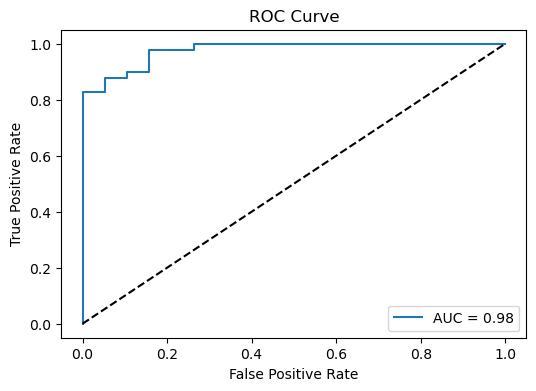

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

lr_acc = lr.score(X_test, y_test)
svm_acc = svm.score(X_test, y_test)
rf_acc = rf.score(X_test, y_test)
gb_acc = gb.score(X_test, y_test)

models = ["Logistic Regression", "SVM", "Random Forest", "Gradient Boosting"]
accuracies = [lr_acc, svm_acc, rf_acc, gb_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("accuracy.png")  
plt.show()


y_pred = gb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix (Gradient Boosting)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

y_prob = gb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("roc_curve.png")
plt.show()

In [39]:
models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

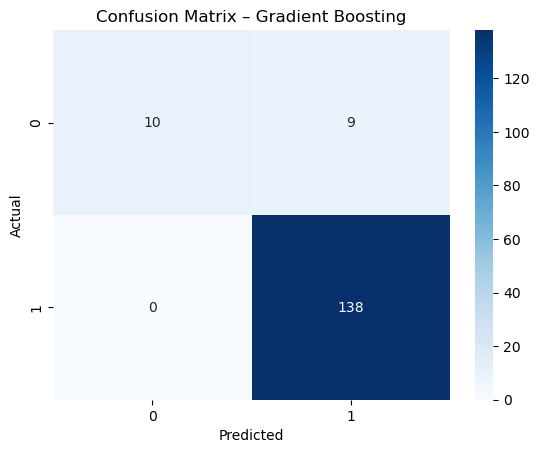

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Gradient Boosting")
plt.show()


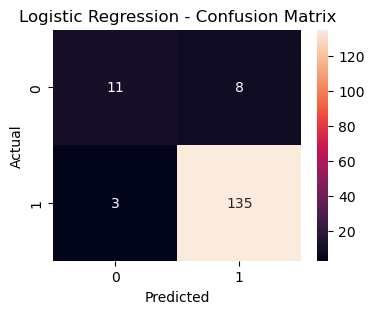

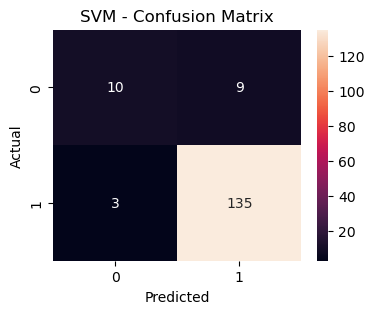

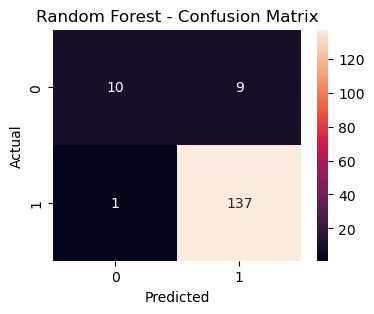

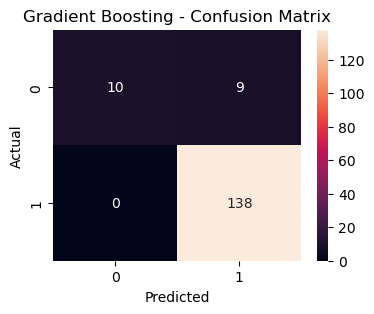

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

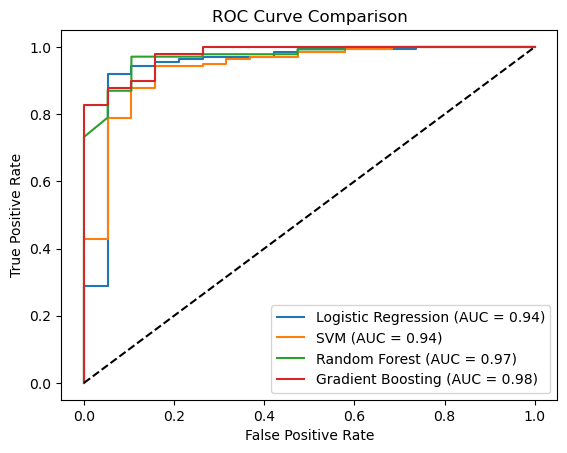

In [45]:
from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [47]:
best_model = gb 
print("Final Selected Model: Gradient Boosting")

Final Selected Model: Gradient Boosting


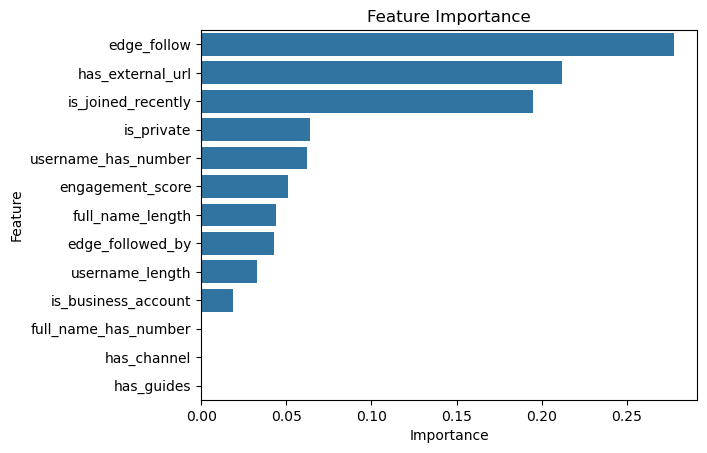

In [49]:
import pandas as pd

importance = best_model.feature_importances_
features = df.drop('is_fake', axis=1).columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=imp_df)
plt.title("Feature Importance")
plt.show()

In [51]:
def predict_profile(input_data):
    input_scaled = scaler.transform(input_data)
    prediction = best_model.predict(input_scaled)

    if prediction[0] == 1:
        return "Fake Profile"
    else:
        return "Real Profile"

In [53]:
sample = pd.DataFrame([X_test[0]], columns=df.drop('is_fake', axis=1).columns)
print(predict_profile(sample))

Real Profile


## Real-World Application

This model can be used by social media platforms to detect fake accounts and improve user security.

## Limitations

- Model depends on dataset quality
- Cannot detect highly sophisticated fake accounts

## Future Enhancements

- Use Deep Learning
- Real-time API integration
- Deploy as web application